# Interpret whole-slide clinical predictions

Run ABMIL inference on HistAgent tile representations, map tile-level scores back to tissue and analyze patient-level prognostic risk.

## Installation

Create a Python 3.10+ environment, install the public HistAgent package and add
the lightweight analysis dependencies used by these notebooks.

```bash
git clone https://github.com/zipging/HistAgent.git
cd HistAgent
python -m venv .venv
source .venv/bin/activate
python -m pip install -e .
python -m pip install jupyter numpy pandas matplotlib seaborn scipy scikit-learn torch huggingface-hub
```

If `data/` is absent, the notebook downloads its data from
`wli13/HistAgent-data`. These examples run without a GPU. Running HistAgent on
new images requires access to the gated Prov-GigaPath model and an authenticated
Hugging Face session.

## Setup

Import the analysis packages, locate the tutorial data and set the plotting style.

In [1]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

configured_data = os.getenv("HISTAGENT_TUTORIAL_DATA", "").strip()
DATA_DIR = Path(configured_data).expanduser() if configured_data else Path("data")
if not DATA_DIR.exists():
    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=["tutorials/**", "manifest.json"],
        )
    )
    DATA_DIR = snapshot / "tutorials"
assert DATA_DIR.exists(), f"Tutorial data not found: {DATA_DIR}"

def rankridge_pack_root(groups):
    configured = os.getenv("HISTAGENT_RANKRIDGE_PACKS", "").strip()
    if configured:
        root = Path(configured).expanduser()
        if not (root / groups[0]).exists():
            root = root / "rankridge_tutorial_packs"
        assert (root / groups[0]).exists(), f"RankRidge pack not found: {root}"
        return root

    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=[
                f"rankridge_tutorial_packs/{group}/**" for group in groups
            ],
        )
    )
    return snapshot / "rankridge_tutorial_packs"

sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "figure.dpi": 135,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#000000",
    "axes.labelcolor": "#000000",
    "axes.linewidth": 1.25,
    "axes.grid": False,
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "text.color": "#000000",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
})
COLORS = {
    "HistAgent": "#168267",
    "Measured ST": "#6f7477",
    "STPath": "#cb77a0",
    "OmiCLIP": "#69aec7",
}
SURVIVAL_COLORS = {"High risk": "#EF4635", "Low risk": "#39B8CE"}
REGION_COLORS = {
    "Poor": "#d85f6b",
    "High": "#79a9d1",
    "Negative": "#b7b7b7",
    "Tumor": "#e32925",
    "Stroma": "#62acec",
}
TASK_CMAPS = {
    "svg": "YlGnBu",
    "domain": "tab10",
    "deconv": "Greens",
    "deg": "Purples",
    "pathway": "PuBuGn",
}

## Overview

Run a trained ABMIL model on HistAgent tile representations, compare the resulting scores across annotated tissue regions and calculate patient-level prognostic risk.

In [2]:
import torch
from torch import nn
from scipy.ndimage import gaussian_filter, maximum_filter
from scipy.stats import mannwhitneyu, chi2

clinical_meta = json.loads((DATA_DIR / "clinical_cases.json").read_text())
survival = pd.read_csv(DATA_DIR / "figure4_survival_oof.csv")
reported = pd.read_json(DATA_DIR / "fig4d_summary.json")

print(f"Clinical examples: {len(clinical_meta['cases'])}")
print(f"Out-of-fold patients: {survival['case_id'].nunique():,}")

Clinical examples: 3
Out-of-fold patients: 842


## Run clinical inference

The instance encoder maps each 512-dimensional HistAgent representation to a 256-dimensional tile representation. The trained prediction head then produces a subtype probability or survival-risk score for each tile. The two STAD examples average predictions from five trained ABMIL models; gated attention aggregates the same tile representations for slide-level prediction.

In [3]:
class GatedAttention(nn.Module):
    def __init__(self, in_dim=256, hidden=256):
        super().__init__()
        self.v = nn.Linear(in_dim, hidden)
        self.u = nn.Linear(in_dim, hidden)
        self.w = nn.Linear(hidden, 1)

    def forward(self, h):
        logits = self.w(
            torch.tanh(self.v(h)) * torch.sigmoid(self.u(h))
        ).squeeze(-1)
        weights = torch.softmax(logits, dim=0)
        return torch.sum(h * weights[:, None], dim=0), weights


class ABMIL(nn.Module):
    def __init__(self, in_dim=512, n_classes=1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.attn = GatedAttention()
        self.head = nn.Linear(256, n_classes)

    def forward(self, x):
        h = self.encoder(x)
        slide, attention = self.attn(h)
        return self.head(slide), attention


class HistAgent:
    """Clinical inference interface used throughout this tutorial."""

    def __init__(self, data_dir, case_metadata, device="cpu", batch_size=4096):
        self.data_dir = Path(data_dir)
        self.case_metadata = {
            row["case"]: row for row in case_metadata["cases"]
        }
        self.device = torch.device(device)
        self.batch_size = batch_size
        self._tile_predictions = {}
        self._slide_predictions = {}

    def _case(self, case_id):
        if case_id not in self.case_metadata:
            raise KeyError(f"Unknown clinical case: {case_id}")
        return self.case_metadata[case_id]

    def load_case(self, case_id):
        """Load one slide's representations, coordinates and ROI labels."""
        info = self._case(case_id)
        with np.load(self.data_dir / info["embedding_file"]) as arrays:
            return {
                "embeddings": arrays["embeddings"].astype(np.float32),
                "coords": arrays["coords"].copy(),
                "region_codes": arrays["regions"].copy(),
            }

    def _checkpoint_files(self, info):
        if "checkpoints" in info:
            return info["checkpoints"]
        return [info["checkpoint"]]

    def _load_abmil(self, info, checkpoint_file):
        model = ABMIL(n_classes=info["n_classes"]).to(self.device)
        state = torch.load(
            self.data_dir / checkpoint_file,
            map_location=self.device,
            weights_only=True,
        )
        model.load_state_dict(state)
        return model.eval()

    def _encode_tiles(self, model, embeddings):
        batches = []
        for start in range(0, len(embeddings), self.batch_size):
            x = torch.from_numpy(
                embeddings[start:start + self.batch_size]
            ).to(self.device)
            batches.append(model.encoder(x))
        return torch.cat(batches)

    def _forward_checkpoint(self, model, embeddings, info):
        with torch.no_grad():
            encoded = self._encode_tiles(model, embeddings)
            tile_logits = model.head(encoded)
            slide_representation, attention = model.attn(encoded)
            slide_logits = model.head(slide_representation)
            if info["n_classes"] > 1:
                tile_score = torch.softmax(tile_logits, dim=1)[
                    :, info["target_index"]
                ]
                slide_score = torch.softmax(slide_logits, dim=0)[
                    info["target_index"]
                ]
            else:
                tile_score = tile_logits[:, 0]
                slide_score = slide_logits[0]
        return (
            tile_score.cpu().numpy(),
            attention.cpu().numpy(),
            float(slide_score.cpu()),
        )

    def predict_tiles(self, case_id):
        """Calculate tile scores and attention weights for one slide."""
        if case_id in self._tile_predictions:
            return self._tile_predictions[case_id].copy()
        info = self._case(case_id)
        case = self.load_case(case_id)
        score_sum = np.zeros(len(case["embeddings"]), dtype=np.float64)
        attention_sum = np.zeros_like(score_sum)
        slide_scores = []
        checkpoints = self._checkpoint_files(info)
        for checkpoint_file in checkpoints:
            model = self._load_abmil(info, checkpoint_file)
            score, attention, slide_score = self._forward_checkpoint(
                model, case["embeddings"], info
            )
            score_sum += score
            attention_sum += attention
            slide_scores.append(slide_score)

        region_labels = [
            "Unannotated" if code < 0 else info["region_names"][int(code)]
            for code in case["region_codes"]
        ]
        frame = pd.DataFrame({
            "cohort": info["cohort"],
            "case": case_id,
            "x": case["coords"][:, 0],
            "y": case["coords"][:, 1],
            "region_code": case["region_codes"],
            "region": region_labels,
            "score": score_sum / len(checkpoints),
            "attention": attention_sum / len(checkpoints),
        })
        self._tile_predictions[case_id] = frame
        self._slide_predictions[case_id] = {
            "cohort": info["cohort"],
            "case": case_id,
            "tiles": len(frame),
            "annotated_tiles": int((frame["region_code"] >= 0).sum()),
            "models": len(checkpoints),
            "slide_score": float(np.mean(slide_scores)),
        }
        return frame.copy()

    def predict_slide(self, case_id):
        """Return the attention-aggregated slide prediction."""
        if case_id not in self._slide_predictions:
            self.predict_tiles(case_id)
        return self._slide_predictions[case_id].copy()

    def run(self, case_ids=None):
        """Run the complete tile- and slide-level inference workflow."""
        case_ids = case_ids or list(self.case_metadata)
        tile_frames = [self.predict_tiles(case_id) for case_id in case_ids]
        slide_rows = [self.predict_slide(case_id) for case_id in case_ids]
        return pd.concat(tile_frames, ignore_index=True), pd.DataFrame(slide_rows)

    def compare_regions(self, frame, region_1, region_2):
        """Test whether scores are higher in region_1 than region_2."""
        a = frame.loc[frame["region"] == region_1, "score"].to_numpy()
        b = frame.loc[frame["region"] == region_2, "score"].to_numpy()
        test = mannwhitneyu(a, b, alternative="greater")
        return {
            "comparison": f"{region_1} > {region_2}",
            "n_1": len(a),
            "n_2": len(b),
            "Mann–Whitney P": test.pvalue,
        }

    def map_scores(
        self, frame, bounds, tile_size, width=900, smooth=False
    ):
        """Map tile footprints to a field in the original WSI coordinates."""
        xmin, ymin, xmax, ymax = bounds
        height = max(1, round(width * (ymax - ymin) / (xmax - xmin)))
        weighted = np.zeros((height, width), dtype=np.float32)
        counts = np.zeros((height, width), dtype=np.float32)
        for row in frame.itertuples():
            left = int(np.floor((row.x - xmin) / (xmax - xmin) * width))
            right = int(np.ceil(
                (row.x + tile_size - xmin) / (xmax - xmin) * width
            ))
            top = int(np.floor((row.y - ymin) / (ymax - ymin) * height))
            bottom = int(np.ceil(
                (row.y + tile_size - ymin) / (ymax - ymin) * height
            ))
            left, right = max(0, left), min(width, right)
            top, bottom = max(0, top), min(height, bottom)
            if left >= right or top >= bottom:
                continue
            weighted[top:bottom, left:right] += row.score
            counts[top:bottom, left:right] += 1
        tissue = counts > 0
        field = np.divide(
            weighted, counts, out=np.zeros_like(weighted), where=tissue
        )
        if smooth:
            sigma = max(0.8, tile_size / (xmax - xmin) * width * 0.6)
            smoothed_weight = gaussian_filter(field * tissue, sigma=sigma)
            smoothed_mask = gaussian_filter(tissue.astype(float), sigma=sigma)
            field = np.divide(
                smoothed_weight, smoothed_mask,
                out=np.zeros_like(field), where=smoothed_mask > 1e-5,
            )
        low, high = np.percentile(field[tissue], [2, 98])
        normalized = np.clip(
            (field - low) / (high - low + 1e-9), 0, 1
        )
        return normalized, tissue

    @staticmethod
    def kaplan_meier(time, event):
        order = np.argsort(time)
        time = np.asarray(time)[order]
        event = np.asarray(event)[order].astype(int)
        event_times = np.unique(time[event == 1])
        surv = 1.0
        variance_sum = 0.0
        xs, ys, lower, upper = [0.0], [1.0], [1.0], [1.0]
        for t in event_times:
            at_risk = np.sum(time >= t)
            deaths = np.sum((time == t) & (event == 1))
            se_before = surv * np.sqrt(variance_sum)
            xs.extend([t, t])
            ys.extend([ys[-1], surv * (1 - deaths / at_risk)])
            lower.append(max(0, surv - 1.96 * se_before))
            upper.append(min(1, surv + 1.96 * se_before))
            if at_risk - deaths > 0:
                variance_sum += deaths / (at_risk * (at_risk - deaths))
            surv = ys[-1]
            se_after = surv * np.sqrt(variance_sum)
            lower.append(max(0, surv - 1.96 * se_after))
            upper.append(min(1, surv + 1.96 * se_after))
        return (
            np.asarray(xs), np.asarray(ys),
            np.asarray(lower), np.asarray(upper),
        )

    @staticmethod
    def logrank_p(time, event, group):
        time = np.asarray(time)
        event = np.asarray(event).astype(int)
        group = np.asarray(group).astype(bool)
        observed = expected = variance = 0.0
        for t in np.unique(time[event == 1]):
            at_risk = time >= t
            n = at_risk.sum()
            n1 = (at_risk & group).sum()
            d = ((time == t) & (event == 1)).sum()
            d1 = ((time == t) & (event == 1) & group).sum()
            if n <= 1:
                continue
            observed += d1
            expected += d * n1 / n
            variance += (
                d * (n1 / n) * (1 - n1 / n) * ((n - d) / (n - 1))
            )
        statistic = (observed - expected) ** 2 / variance
        return chi2.sf(statistic, 1)


agent = HistAgent(DATA_DIR, clinical_meta)
tiles, inference_summary = agent.run()
display(inference_summary.round(3))
tiles.query("region_code >= 0").groupby(
    ["cohort", "case", "region"]
).agg(
    tiles=("score", "size"),
    mean_score=("score", "mean"),
).round(3)

,cohort,case,tiles,annotated_tiles,models,slide_score
0,STAD,TCGA-VQ-AA6B,73724,28679,5,0.993
1,STAD,TCGA-BR-8486,77760,62494,5,0.973
2,BRCA,TCGA-E2-A1LH,75260,145,1,-1.644


tiles  mean_score
cohort case         region                   
BRCA   TCGA-E2-A1LH Stroma     66      -3.204
                    Tumor      79      -0.918
STAD   TCGA-BR-8486 High    10112       0.200
                    Poor    52382       0.452
       TCGA-VQ-AA6B High      318       0.316
                    Poor    28361       0.729

## Compare annotated tissue regions

The same tile scores are used for the spatial maps and the region-level tests. STAD compares poorly and highly differentiated tissue; BRCA compares tumor and stroma within the annotated ROI.

In [4]:
expected_region_pairs = {
    "STAD": ("Poor", "High"),
    "BRCA": ("Tumor", "Stroma"),
}
region_tests = []
for (cohort, case), frame in tiles.groupby(["cohort", "case"]):
    region_1, region_2 = expected_region_pairs[cohort]
    result = agent.compare_regions(frame, region_1, region_2)
    region_tests.append({
        "cohort": cohort,
        "case": case,
        **result,
    })
region_tests = pd.DataFrame(region_tests)
region_tests

,cohort,case,comparison,n_1,n_2,Mann–Whitney P
0,BRCA,TCGA-E2-A1LH,Tumor > Stroma,79,66,6.375774e-12
1,STAD,TCGA-BR-8486,Poor > High,52382,10112,0.000000e+00
2,STAD,TCGA-VQ-AA6B,Poor > High,28361,318,3.835881e-86


## Spatial visualization of clinical scores

Map the computed tile-level scores back to the two STAD whole-slide examples and the BRCA ROI.

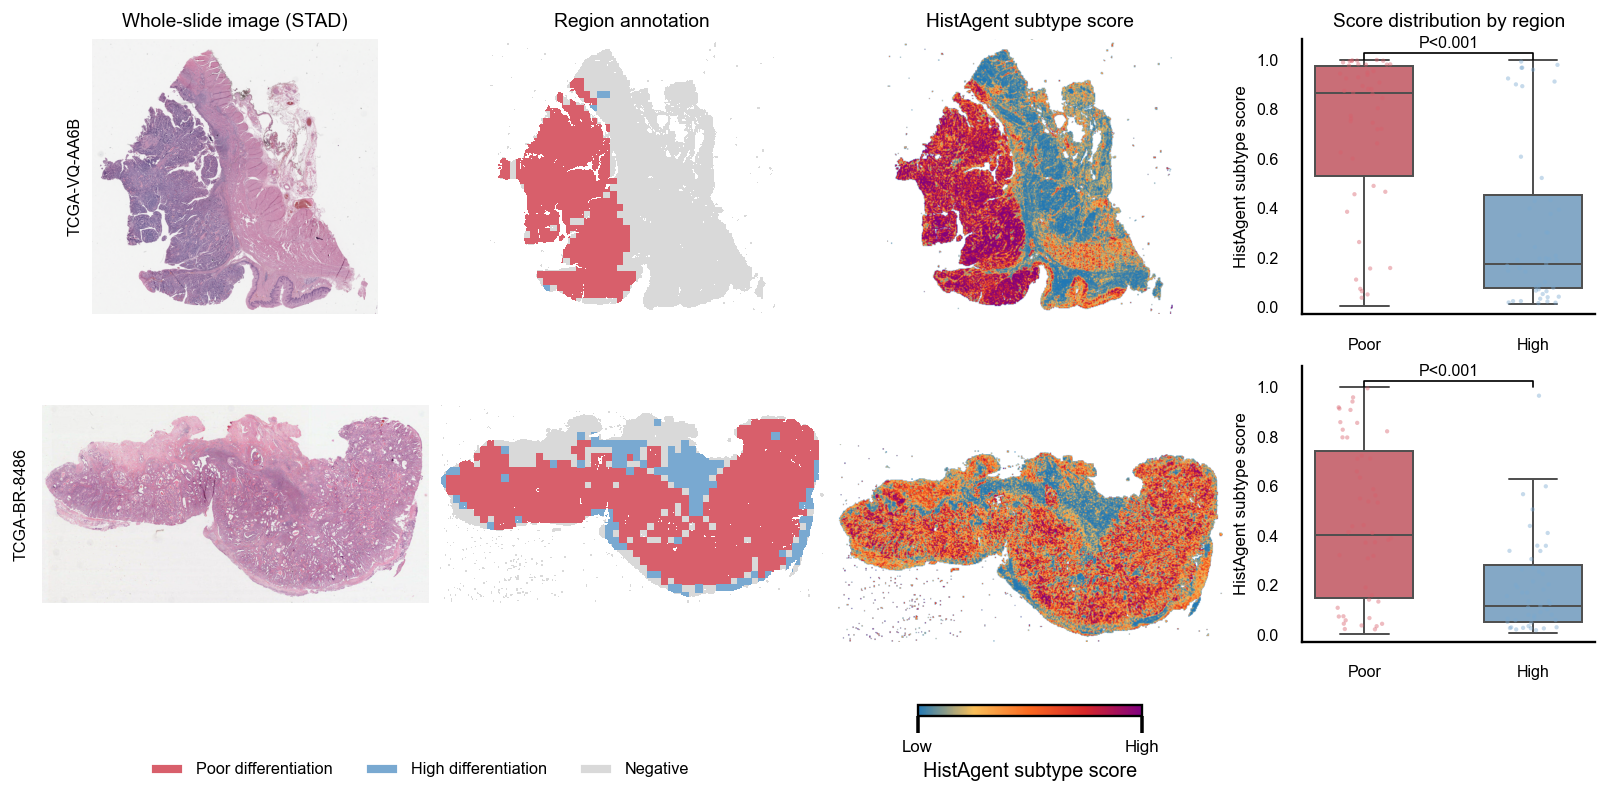

In [5]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgba
from matplotlib.patches import Patch, Rectangle, Polygon

wsi_dir = DATA_DIR / "figure4_wsi"
risk_cmap = LinearSegmentedColormap.from_list(
    "histagent_risk",
    ["#2178B5", "#F9BF59", "#FA681F", "#D62629", "#800080"],
)

def slide_bounds(info):
    return (0, 0, info["slide_width"], info["slide_height"])

def show_image(ax, filename, bounds):
    xmin, ymin, xmax, ymax = bounds
    ax.imshow(
        plt.imread(wsi_dir / filename),
        extent=[xmin, xmax, ymax, ymin],
        origin="upper",
    )
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymax, ymin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_axis_off()

def score_raster(
    frame, bounds, tile_size, width=900, smooth=False,
    valid_mask=None, alpha=1.0,
):
    normalized, tissue = agent.map_scores(
        frame, bounds, tile_size, width=width, smooth=smooth
    )
    if valid_mask is not None:
        if valid_mask.shape != tissue.shape:
            raise ValueError(
                f"Mask shape {valid_mask.shape} does not match "
                f"score field {tissue.shape}"
            )
        tissue &= valid_mask
    rgba = risk_cmap(normalized)
    rgba[..., 3] = np.where(tissue, alpha, 0.0)
    return rgba

def _raster_geometry(bounds, width=900):
    xmin, ymin, xmax, ymax = bounds
    height = max(1, round(width * (ymax - ymin) / (xmax - xmin)))
    return int(width), int(height)

def region_raster(frame, bounds, width=900):
    xmin, ymin, xmax, ymax = bounds
    width, height = _raster_geometry(bounds, width)
    x_index = np.clip(
        ((frame["x"].to_numpy() - xmin) / (xmax - xmin) * (width - 1)).astype(int),
        0, width - 1,
    )
    y_index = np.clip(
        ((frame["y"].to_numpy() - ymin) / (ymax - ymin) * (height - 1)).astype(int),
        0, height - 1,
    )
    rgba = np.zeros((height, width, 4), dtype=float)
    for code, color in [
        (-1, "#D9D9D9"),
        (0, REGION_COLORS["Poor"]),
        (1, REGION_COLORS["High"]),
    ]:
        mask = np.zeros((height, width), dtype=np.uint8)
        selected = frame["region_code"].to_numpy() == code
        mask[y_index[selected], x_index[selected]] = 1
        mask = maximum_filter(mask, size=3) > 0
        rgba[mask] = to_rgba(color)
    return rgba

def show_raster(ax, rgba, bounds, interpolation="nearest"):
    xmin, ymin, xmax, ymax = bounds
    ax.imshow(
        rgba, extent=[xmin, xmax, ymax, ymin],
        origin="upper", interpolation=interpolation,
    )
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymax, ymin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_axis_off()

stad_cases = [case for case in clinical_meta["cases"] if case["cohort"] == "STAD"]
fig, axes = plt.subplots(
    2, 4, figsize=(11.8, 5.75),
    gridspec_kw={"width_ratios": [1.08, 1.08, 1.08, .82]},
    constrained_layout=True,
)
column_titles = [
    "Whole-slide image (STAD)",
    "Region annotation",
    "HistAgent subtype score",
    "Score distribution by region",
]

for row_i, info in enumerate(stad_cases):
    bounds = slide_bounds(info)
    case_id = info["case"]
    frame = tiles.query("cohort == 'STAD' and case == @case_id").copy()
    annotated = frame.query("region_code >= 0").copy()

    show_image(axes[row_i, 0], info["thumbnail"], bounds)
    show_raster(axes[row_i, 1], region_raster(frame, bounds), bounds)
    show_raster(
        axes[row_i, 2],
        score_raster(
            frame, bounds, info["tile_size_level0_px"]
        ),
        bounds,
        interpolation="bilinear",
    )

    order = ["Poor", "High"]
    point_sample = pd.concat([
        part.sample(min(len(part), 48), random_state=11)
        for _, part in annotated.groupby("region", sort=False)
    ])
    sns.boxplot(
        data=annotated, x="region", y="score", order=order, hue="region",
        palette=REGION_COLORS, showfliers=False, width=.58,
        linewidth=1.05, legend=False, ax=axes[row_i, 3],
    )
    sns.stripplot(
        data=point_sample, x="region", y="score", order=order, hue="region",
        palette=REGION_COLORS, size=2.3, alpha=.42,
        jitter=.16, legend=False, ax=axes[row_i, 3],
    )
    poor = annotated.loc[annotated["region"] == "Poor", "score"].to_numpy()
    high = annotated.loc[annotated["region"] == "High", "score"].to_numpy()
    p_value = mannwhitneyu(poor, high, alternative="greater").pvalue
    axes[row_i, 3].plot(
        [0, 0, 1, 1], [1.00, 1.025, 1.025, 1.00],
        color="black", linewidth=.9,
    )
    axes[row_i, 3].text(
        .5, 1.035, "P<0.001" if p_value < .001 else f"P={p_value:.3f}",
        ha="center", va="bottom", fontsize=8.5,
    )
    axes[row_i, 3].set_ylim(-.03, 1.085)
    axes[row_i, 3].set_xlabel("")
    axes[row_i, 3].set_ylabel("HistAgent subtype score", fontsize=9)
    axes[row_i, 3].tick_params(labelsize=8.5, colors="black")
    sns.despine(ax=axes[row_i, 3])

    axes[row_i, 0].text(
        -.035, .5, info["case"], transform=axes[row_i, 0].transAxes,
        rotation=90, va="center", ha="right", fontsize=8.5,
    )
    if row_i == 0:
        for ax, title in zip(axes[row_i], column_titles):
            ax.set_title(title, pad=6, fontsize=10.2)

fig.legend(
    handles=[
        Patch(facecolor=REGION_COLORS["Poor"], label="Poor differentiation"),
        Patch(facecolor=REGION_COLORS["High"], label="High differentiation"),
        Patch(facecolor="#D9D9D9", label="Negative"),
    ],
    loc="lower left", bbox_to_anchor=(.08, -.01), ncol=3,
    frameon=False, fontsize=8.7,
)
fig.colorbar(
    ScalarMappable(norm=Normalize(0, 1), cmap=risk_cmap),
    ax=axes[:, 2].tolist(), orientation="horizontal",
    shrink=.58, pad=.035, label="HistAgent subtype score",
    ticks=[0, 1],
)
colorbar = fig.axes[-1]
colorbar.set_xticklabels(["Low", "High"])
plt.show()

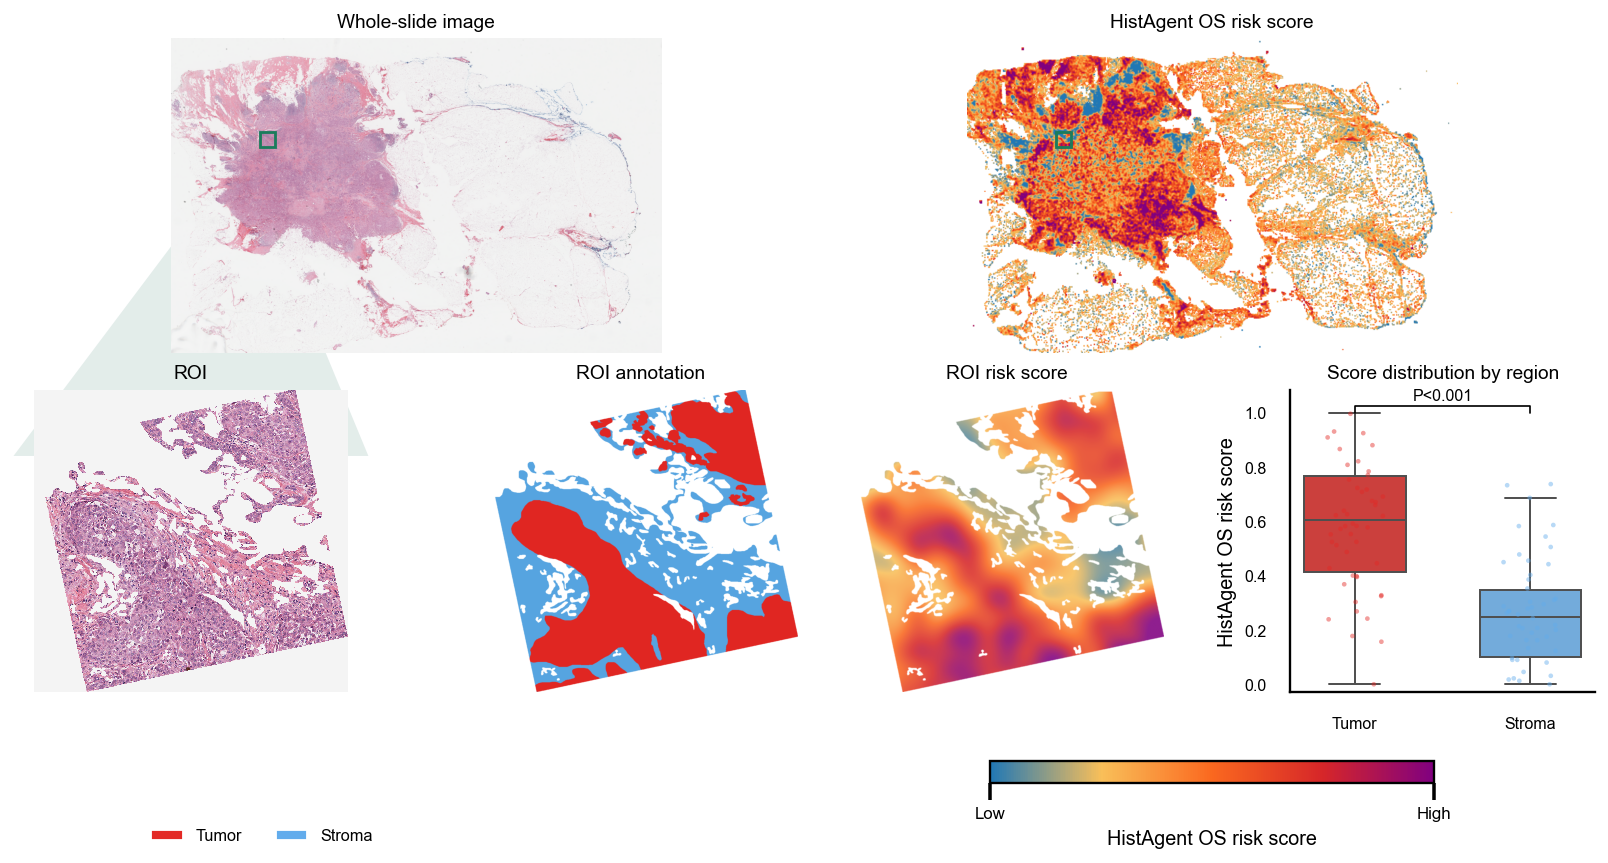

In [6]:
brca_info = next(
    case for case in clinical_meta["cases"] if case["cohort"] == "BRCA"
)
brca_frame = tiles.query("cohort == 'BRCA'").copy()
brca_annotated = brca_frame.query("region_code >= 0").copy()
full_bounds = slide_bounds(brca_info)
roi_bounds = tuple(brca_info["roi_bounds"][key] for key in [
    "xmin", "ymin", "xmax", "ymax"
])
roi_frame = brca_frame.loc[
    brca_frame["x"].between(roi_bounds[0], roi_bounds[2])
    & brca_frame["y"].between(roi_bounds[1], roi_bounds[3])
].copy()
fig = plt.figure(figsize=(11.8, 6.25), constrained_layout=True)
grid = fig.add_gridspec(
    2, 4, height_ratios=[1.04, 1],
    width_ratios=[1, 1, 1, .86],
)
brca_axes = {
    "wsi": fig.add_subplot(grid[0, :2]),
    "wsi_score": fig.add_subplot(grid[0, 2:]),
    "roi": fig.add_subplot(grid[1, 0]),
    "roi_region": fig.add_subplot(grid[1, 1]),
    "roi_score": fig.add_subplot(grid[1, 2]),
    "distribution": fig.add_subplot(grid[1, 3]),
}
show_image(
    brca_axes["wsi"], brca_info["thumbnail"], full_bounds
)
brca_axes["wsi"].set_title("Whole-slide image", pad=6, fontsize=10.2)
brca_axes["wsi"].add_patch(Rectangle(
    (roi_bounds[0], roi_bounds[1]),
    roi_bounds[2] - roi_bounds[0],
    roi_bounds[3] - roi_bounds[1],
    fill=False, edgecolor="#1B7C5C", linewidth=1.5,
))

show_raster(
    brca_axes["wsi_score"],
    score_raster(
        brca_frame, full_bounds,
        brca_info["tile_size_level0_px"],
        width=1000, smooth=True,
    ),
    full_bounds,
    interpolation="bilinear",
)
brca_axes["wsi_score"].set_title(
    "HistAgent OS risk score", pad=6, fontsize=10.2
)
brca_axes["wsi_score"].add_patch(Rectangle(
    (roi_bounds[0], roi_bounds[1]),
    roi_bounds[2] - roi_bounds[0],
    roi_bounds[3] - roi_bounds[1],
    fill=False, edgecolor="#1B7C5C", linewidth=1.5,
))

roi_image_array = plt.imread(wsi_dir / brca_info["roi_image"])
roi_annotation_array = plt.imread(
    wsi_dir / brca_info["roi_annotation"]
)
roi_valid_mask = np.any(
    roi_annotation_array[..., :3] < .98, axis=2
)
roi_image_masked = roi_image_array[..., :3].copy()
roi_image_masked[~roi_valid_mask] = .96
show_raster(
    brca_axes["roi"], roi_image_masked, roi_bounds,
    interpolation="nearest",
)
brca_axes["roi"].set_title("ROI", pad=6, fontsize=10.2)
show_image(
    brca_axes["roi_region"], brca_info["roi_annotation"], roi_bounds
)
brca_axes["roi_region"].set_title("ROI annotation", pad=6, fontsize=10.2)
show_raster(
    brca_axes["roi_score"],
    score_raster(
        roi_frame, roi_bounds, brca_info["tile_size_level0_px"],
        width=roi_image_array.shape[1], smooth=True,
        valid_mask=roi_valid_mask, alpha=.88,
    ),
    roi_bounds,
    interpolation="bilinear",
)
brca_axes["roi_score"].set_title("ROI risk score", pad=6, fontsize=10.2)

distribution_ax = brca_axes["distribution"]
order = ["Tumor", "Stroma"]
score_low, score_high = np.percentile(
    brca_annotated["score"], [2, 98]
)
brca_annotated["display_score"] = np.clip(
    (brca_annotated["score"] - score_low)
    / (score_high - score_low + 1e-9),
    0, 1,
)
point_sample = pd.concat([
    part.sample(min(len(part), 48), random_state=8)
    for _, part in brca_annotated.groupby("region", sort=False)
])
sns.boxplot(
    data=brca_annotated, x="region", y="display_score",
    order=order, hue="region",
    palette=REGION_COLORS, showfliers=False, width=.58,
    linewidth=1.05, legend=False, ax=distribution_ax,
)
sns.stripplot(
    data=point_sample, x="region", y="display_score",
    order=order, hue="region",
    palette=REGION_COLORS, size=2.5, alpha=.45, jitter=.16,
    legend=False, ax=distribution_ax,
)
p_value = region_tests.query("cohort == 'BRCA'")["Mann–Whitney P"].iloc[0]
distribution_ax.set_title("Score distribution by region", pad=6, fontsize=10.2)
distribution_ax.set_xlabel("")
distribution_ax.set_ylabel("HistAgent OS risk score")
distribution_ax.plot(
    [0, 0, 1, 1], [1.00, 1.025, 1.025, 1.00],
    color="black", linewidth=.9,
)
distribution_ax.text(
    .5, 1.035, "P<0.001" if p_value < .001 else f"P={p_value:.3f}",
    ha="center", va="bottom", fontsize=8.5,
)
distribution_ax.set_ylim(-.03, 1.085)
distribution_ax.tick_params(labelsize=8.5, colors="black")
sns.despine(ax=distribution_ax)

fig.canvas.draw()
roi_wsi_points = [
    brca_axes["wsi"].transData.transform(
        (roi_bounds[0], roi_bounds[3])
    ),
    brca_axes["wsi"].transData.transform(
        (roi_bounds[2], roi_bounds[3])
    ),
]
roi_panel_points = [
    brca_axes["roi"].transAxes.transform((0, 1)),
    brca_axes["roi"].transAxes.transform((1, 1)),
]
connector_points = [
    fig.transFigure.inverted().transform(point)
    for point in roi_wsi_points + roi_panel_points[::-1]
]
fig.patches.append(Polygon(
    connector_points,
    transform=fig.transFigure,
    facecolor="#D9E6E3",
    edgecolor="none",
    alpha=.72,
    zorder=-1,
))

fig.legend(
    handles=[
        Patch(facecolor=REGION_COLORS["Tumor"], label="Tumor"),
        Patch(facecolor=REGION_COLORS["Stroma"], label="Stroma"),
    ],
    loc="lower left", bbox_to_anchor=(0.08, -0.008),
    ncol=2, frameon=False, fontsize=8.7,
)
fig.colorbar(
    ScalarMappable(
        norm=Normalize(0, 1), cmap=risk_cmap
    ),
    ax=[brca_axes["wsi_score"], brca_axes["roi_score"]],
    location="bottom", shrink=.58, pad=.04,
    label="HistAgent OS risk score",
    ticks=[0, 1],
)
colorbar = fig.axes[-1]
colorbar.set_xticklabels(["Low", "High"])
plt.show()

## Patient-level prognostic-risk stratification

Each cohort is split at its median out-of-fold risk. The code below calculates the Kaplan-Meier curves and log-rank p-values.

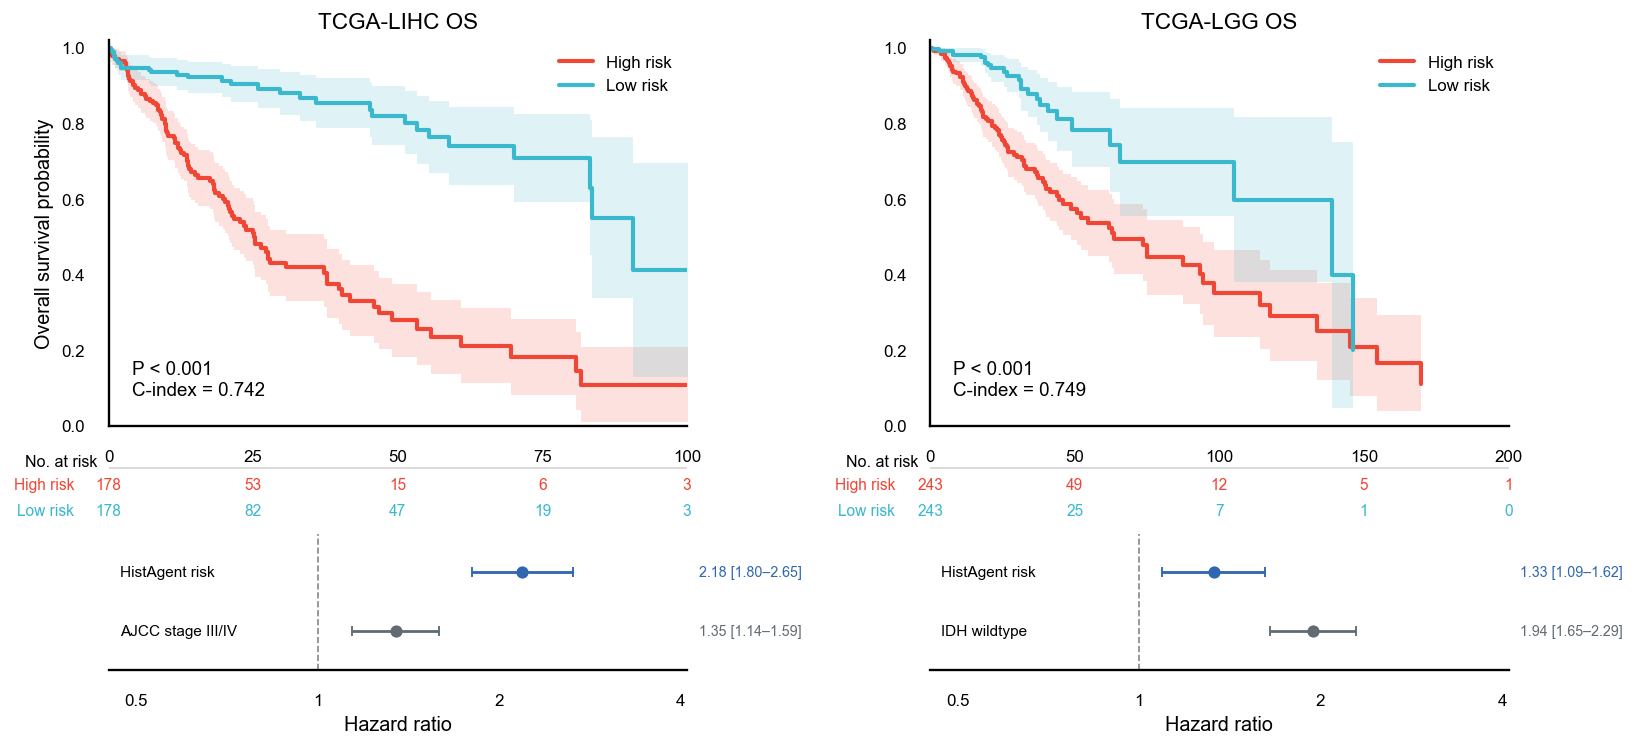

,Cohort,C-index,Log-rank P
0,LIHC,0.742,0.0
1,LGG,0.749,0.0


In [7]:
survival["cohort"] = survival["task"].str.replace("TCGA-", "", regex=False)
survival["cohort"] = survival["cohort"].str.replace("__OS", "", regex=False)
survival["risk_group"] = survival.groupby("cohort")["risk"].transform(
    lambda x: np.where(x >= x.median(), "High risk", "Low risk")
)

cohort_order = ["LIHC", "LGG"]
time_ticks = {
    "LIHC": np.array([0, 25, 50, 75, 100]),
    "LGG": np.array([0, 50, 100, 150, 200]),
}
cox_rows = reported.query("analysis == 'Cox'").copy()
fig = plt.figure(figsize=(12.2, 5.55), facecolor="white")
outer = fig.add_gridspec(
    1, 2, left=.075, right=.925, top=.94, bottom=.10, wspace=.42
)
km_results = []
for column_index, cohort in enumerate(cohort_order):
    frame = survival.query("cohort == @cohort").copy()
    subgrid = outer[column_index].subgridspec(
        3, 1, height_ratios=[3.35, .66, 1.18], hspace=.08
    )
    ax = fig.add_subplot(subgrid[0])
    risk_ax = fig.add_subplot(subgrid[1], sharex=ax)
    forest_ax = fig.add_subplot(subgrid[2])

    for group in ["High risk", "Low risk"]:
        color = SURVIVAL_COLORS[group]
        part = frame.query("risk_group == @group")
        x, y, low, high = agent.kaplan_meier(
            part["time"], part["event"]
        )
        ax.fill_between(
            x, low, high, step="post", color=color, alpha=.16, linewidth=0
        )
        ax.step(x, y, where="post", label=group,
                color=color, linewidth=2.2)
    p = agent.logrank_p(
        frame["time"], frame["event"],
        frame["risk_group"].eq("High risk"),
    )
    c_index = float(
        reported.query(
            "cohort == @cohort and analysis == 'Kaplan–Meier' "
            "and quantity_or_covariate == 'C-index'"
        )["estimate"].iloc[0]
    )
    km_results.append({
        "Cohort": cohort, "C-index": c_index, "Log-rank P": p
    })
    ax.set_title(f"TCGA-{cohort} OS")
    ax.set_ylabel(
        "Overall survival probability" if column_index == 0 else ""
    )
    ax.set_ylim(0, 1.02)
    ax.set_xlim(0, time_ticks[cohort][-1])
    ax.set_xticks(time_ticks[cohort])
    p_label = "P < 0.001" if p < .001 else f"P = {p:.3f}"
    ax.text(
        .04, .08, f"{p_label}\nC-index = {c_index:.3f}",
        transform=ax.transAxes,
    )
    ax.legend(frameon=False, loc="upper right")
    sns.despine(ax=ax)

    risk_ax.set_ylim(0, 1)
    risk_ax.set_axis_off()
    risk_ax.text(
        -.02, .73, "No. at risk", transform=risk_ax.transAxes,
        ha="right", va="center", fontsize=8.5,
    )
    group_rows = [("High risk", .43), ("Low risk", .09)]
    for group, y_position in group_rows:
        color = SURVIVAL_COLORS[group]
        group_mask = frame["risk_group"].eq(group).to_numpy()
        risk_ax.text(
            -.06, y_position, group, transform=risk_ax.transAxes,
            ha="right", va="center", fontsize=8.3, color=color,
        )
        for tick in time_ticks[cohort]:
            count = int(
                ((frame["time"].to_numpy() >= tick) & group_mask).sum()
            )
            risk_ax.text(
                tick, y_position, str(count),
                ha="center", va="center", fontsize=8.3, color=color,
            )
    risk_ax.axhline(.66, color="#D0D0D0", linewidth=.8)

    cohort_forest = cox_rows.query("cohort == @cohort").reset_index(drop=True)
    forest_ax.axvline(1, color="#888888", linestyle="--", linewidth=.9)
    y_positions = [1, 0]
    for y_position, row in zip(y_positions, cohort_forest.itertuples()):
        is_histagent = str(row.quantity_or_covariate).startswith("HistAgent")
        color = "#2F67B1" if is_histagent else "#626B73"
        forest_ax.errorbar(
            row.hazard_ratio, y_position,
            xerr=[[row.hazard_ratio - row.ci_low],
                  [row.ci_high - row.hazard_ratio]],
            fmt="o", color=color, ecolor=color, capsize=2.5,
            markersize=5.5, linewidth=1.5,
        )
        label = (
            "HistAgent risk"
            if is_histagent else str(row.quantity_or_covariate)
        )
        forest_ax.text(
            .47, y_position, label,
            ha="left", va="center", fontsize=8.2,
        )
        forest_ax.text(
            1.02, y_position,
            f"{row.hazard_ratio:.2f} [{row.ci_low:.2f}–{row.ci_high:.2f}]",
            transform=forest_ax.get_yaxis_transform(),
            ha="left", va="center", fontsize=7.6, color=color,
        )
    forest_ax.set_xscale("log")
    forest_ax.set_xlim(.45, 4.1)
    forest_ax.set_xticks([.5, 1, 2, 4], labels=["0.5", "1", "2", "4"])
    forest_ax.set_ylim(-.65, 1.65)
    forest_ax.set_yticks([])
    forest_ax.set_xlabel("Hazard ratio")
    forest_ax.minorticks_off()
    sns.despine(ax=forest_ax, left=True)

plt.show()
pd.DataFrame(km_results).round(3)

## Multivariable prognostic analysis

The forest plot uses the reported Cox model estimates. HistAgent risk is entered per standard deviation together with the cohort-specific clinical covariate.

In [8]:
forest_table = reported.query("analysis == 'Cox'").rename(columns={
    "cohort": "Cohort",
    "quantity_or_covariate": "Covariate",
    "hazard_ratio": "Hazard ratio",
}).copy()
forest_table["95% CI"] = forest_table.apply(
    lambda row: f"{row['ci_low']:.2f}–{row['ci_high']:.2f}", axis=1
)
forest_table[["Cohort", "Covariate", "Hazard ratio", "95% CI"]]

,Cohort,Covariate,Hazard ratio,95% CI
5,LIHC,HistAgent risk per 1 SD,2.18,1.80–2.65
6,LIHC,AJCC stage III/IV,1.35,1.14–1.59
12,LGG,HistAgent risk per 1 SD,1.33,1.09–1.62
13,LGG,IDH wildtype,1.94,1.65–2.29


## Verify the calculations

In [9]:
assert len(clinical_meta["cases"]) == 3
for info in clinical_meta["cases"]:
    checkpoint_files = (
        info["checkpoints"]
        if "checkpoints" in info
        else [info["checkpoint"]]
    )
    assert all((DATA_DIR / path).exists() for path in checkpoint_files)
    with np.load(DATA_DIR / info["embedding_file"]) as case_arrays:
        assert (
            len(case_arrays["embeddings"])
            == len(case_arrays["coords"])
            == len(case_arrays["regions"])
        )
        assert len(case_arrays["embeddings"]) > 70_000
assert not survival["case_id"].duplicated().any()
assert set(survival["cohort"]) == {"LIHC", "LGG"}
assert all((wsi_dir / info["thumbnail"]).exists() for info in clinical_meta["cases"])
assert (wsi_dir / brca_info["roi_image"]).exists()
assert (wsi_dir / brca_info["roi_annotation"]).exists()
reported_n = (
    reported.query("analysis == 'Kaplan–Meier' and quantity_or_covariate == 'patients'")
    .set_index("cohort")["estimate"].astype(int).to_dict()
)
for cohort, frame in survival.groupby("cohort"):
    assert len(frame) == reported_n[cohort]
    assert frame["risk_group"].value_counts().nunique() == 1
assert reported_n == {"LIHC": 356, "LGG": 486}
assert len(region_tests) == 3
assert np.isfinite(region_tests["Mann–Whitney P"]).all()
assert tiles.groupby("case").size().min() > 70_000
print("Checks passed for full-slide ABMIL inference, three region contrasts and two patient cohorts.")

Checks passed for full-slide ABMIL inference, three region contrasts and two patient cohorts.


## Continue

Continue to **ST atlas retrieval** to visualize the spatial transcriptomics atlas and run natural-language and H&E image queries.